<a href="https://colab.research.google.com/github/sarabriaz-lgtm/genAI/blob/main/WA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib requests

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from datetime import datetime

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
def get_daily_rainfall(latitude, longitude, start_date, end_date):

    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters=PRECTOTCORR"
        f"&community=AG"
        f"&longitude={longitude}"
        f"&latitude={latitude}"
        f"&start={start_date.strftime('%Y%m%d')}"
        f"&end={end_date.strftime('%Y%m%d')}"
        f"&format=JSON"
    )

    response = requests.get(url, timeout=60)

    if response.status_code != 200:
        raise Exception(
            f"NASA POWER API Error: {response.status_code}\n"
            f"{response.text}"
        )

    data = response.json()

    rainfall_data = data["properties"]["parameter"]["PRECTOTCORR"]

    df = pd.DataFrame(
        list(rainfall_data.items()),
        columns=["date", "rainfall_mm"]
    )

    df["date"] = pd.to_datetime(df["date"])

    df["rainfall_mm"] = pd.to_numeric(
        df["rainfall_mm"],
        errors="coerce"
    )

    df = df.sort_values("date").reset_index(drop=True)

    return df

In [5]:
latitude = 34.500
longitude = 72.500

start_date = pd.Timestamp("2000-01-01")
end_date = pd.Timestamp("2020-12-31")

rainfall_df = get_daily_rainfall(
    latitude,
    longitude,
    start_date,
    end_date
)

rainfall_df.head()

,date,rainfall_mm
0,2000-01-01,0.0
1,2000-01-02,0.0
2,2000-01-03,0.0
3,2000-01-04,0.0
4,2000-01-05,0.0


In [6]:
print("Number of daily records:", len(rainfall_df))

Number of daily records: 7671


In [7]:
def calculate_scs_cn(rainfall_df, catchment_area_km2, curve_number):

    # Calculate S
    S = (25400 / curve_number) - 254

    # Initial abstraction
    Ia = 0.2 * S

    df = rainfall_df.copy()

    # Daily runoff
    df["runoff_mm"] = np.where(
        df["rainfall_mm"] > Ia,
        ((df["rainfall_mm"] - Ia) ** 2) /
        (df["rainfall_mm"] - Ia + S),
        0
    )

    # Convert runoff depth to volume
    df["runoff_m3"] = (
        df["runoff_mm"]
        * catchment_area_km2
        * 1000
    )

    return df, S, Ia

In [8]:
catchment_area_km2 = 250
curve_number = 75

results_df, S, Ia = calculate_scs_cn(
    rainfall_df,
    catchment_area_km2,
    curve_number
)

print("Curve Number:", curve_number)
print("Potential Retention S:", round(S, 2), "mm")
print("Initial Abstraction Ia:", round(Ia, 2), "mm")

Curve Number: 75
Potential Retention S: 84.67 mm
Initial Abstraction Ia: 16.93 mm


In [9]:
total_rainfall = results_df["rainfall_mm"].sum()

total_runoff_depth = results_df["runoff_mm"].sum()

total_runoff_volume = results_df["runoff_m3"].sum()

print("Total rainfall:", round(total_rainfall, 2), "mm")

print(
    "Total runoff depth:",
    round(total_runoff_depth, 2),
    "mm"
)

print(
    "Total runoff volume:",
    round(total_runoff_volume, 2),
    "m3"
)

print(
    "Total runoff volume:",
    round(total_runoff_volume / 1e6, 2),
    "MCM"
)

Total rainfall: 16207.76 mm
Total runoff depth: 574.81 mm
Total runoff volume: 143701588.92 m3
Total runoff volume: 143.7 MCM


In [10]:
results_df["year"] = results_df["date"].dt.year

annual_results = results_df.groupby("year").agg(
    rainfall_mm=("rainfall_mm", "sum"),
    runoff_mm=("runoff_mm", "sum"),
    runoff_m3=("runoff_m3", "sum")
).reset_index()

annual_results["runoff_MCM"] = (
    annual_results["runoff_m3"] / 1e6
)

annual_results

,year,rainfall_mm,runoff_mm,runoff_m3,runoff_MCM
0,2000,259.95,1.429391,3.573477e+05,0.357348
1,2001,272.59,0.267802,6.695062e+04,0.066951
2,2002,390.65,10.686584,2.671646e+06,2.671646
3,2003,553.38,12.867613,3.216903e+06,3.216903
4,2004,345.84,0.387726,9.693146e+04,0.096931
5,2005,517.07,5.948401,1.487100e+06,1.487100
6,2006,857.60,18.517829,4.629457e+06,4.629457
7,2007,742.98,19.817174,4.954294e+06,4.954294
8,2008,933.97,42.375464,1.059387e+07,10.593866
9,2009,641.10,16.266791,4.066698e+06,4.066698


In [11]:
average_annual_runoff = annual_results["runoff_MCM"].mean()

median_annual_runoff = annual_results["runoff_MCM"].median()

minimum_annual_runoff = annual_results["runoff_MCM"].min()

maximum_annual_runoff = annual_results["runoff_MCM"].max()

print("Average annual runoff:", round(average_annual_runoff, 2), "MCM")

print("Median annual runoff:", round(median_annual_runoff, 2), "MCM")

print("Minimum annual runoff:", round(minimum_annual_runoff, 2), "MCM")

print("Maximum annual runoff:", round(maximum_annual_runoff, 2), "MCM")

Average annual runoff: 6.84 MCM
Median annual runoff: 2.67 MCM
Minimum annual runoff: 0.07 MCM
Maximum annual runoff: 65.48 MCM


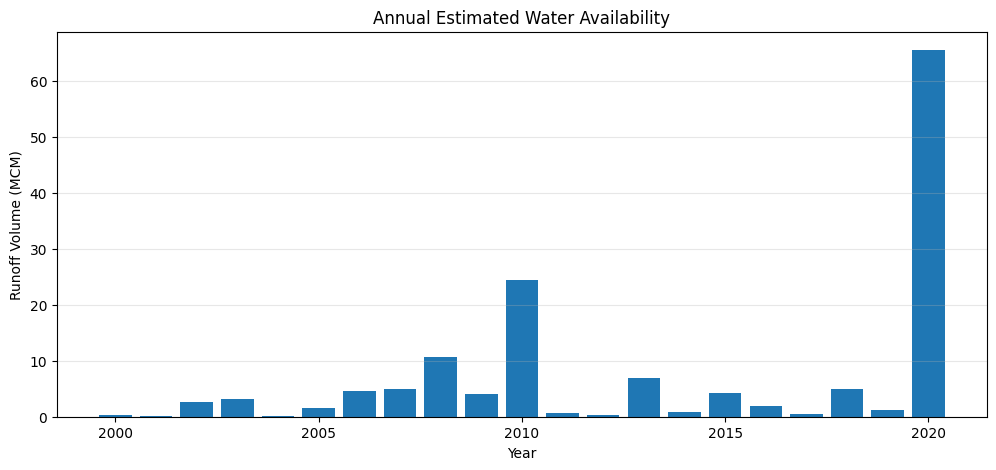

In [12]:
plt.figure(figsize=(12, 5))

plt.bar(
    annual_results["year"],
    annual_results["runoff_MCM"]
)

plt.xlabel("Year")
plt.ylabel("Runoff Volume (MCM)")
plt.title("Annual Estimated Water Availability")

plt.grid(axis="y", alpha=0.3)

plt.show()

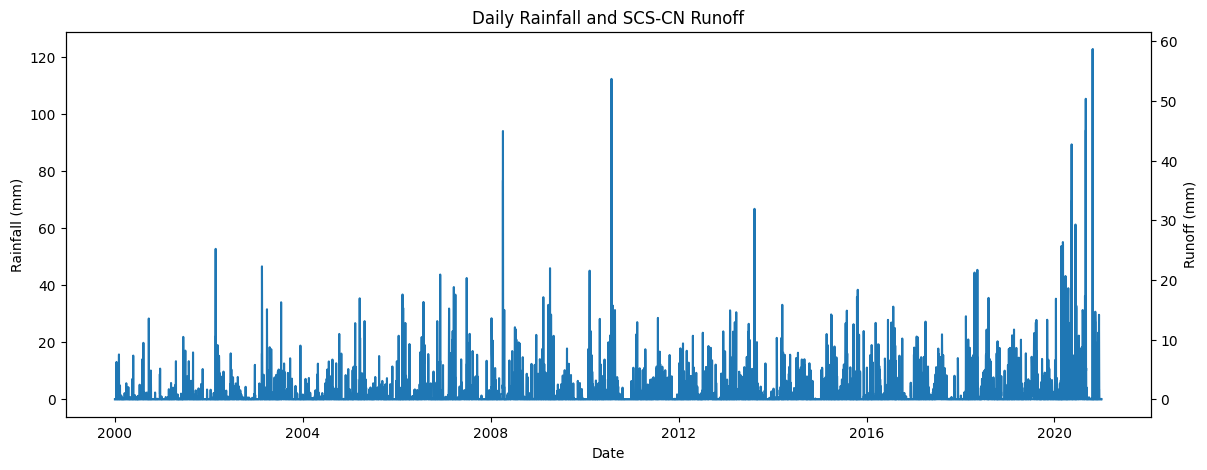

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    results_df["date"],
    results_df["rainfall_mm"],
    label="Daily Rainfall"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Rainfall (mm)")

ax2 = ax1.twinx()

ax2.plot(
    results_df["date"],
    results_df["runoff_mm"],
    label="Daily Runoff"
)

ax2.set_ylabel("Runoff (mm)")

plt.title("Daily Rainfall and SCS-CN Runoff")

plt.show()

In [14]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.5 MB/s eta 0:00:00


In [15]:
!streamlit run app.py &>/content/streamlit.log &

In [16]:
!cat /content/streamlit.log



2026-09-10 17:52:05.822 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.231.19.189:8501



In [17]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared

In [18]:
!chmod +x /content/cloudflared

In [19]:
!nohup /content/cloudflared tunnel --url http://localhost:8501 > /content/cloudflare.log 2>&1 &

In [20]:
!cat /content/cloudflare.log

2026-09-10T17:54:43Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-10T17:54:43Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-10T17:54:47Z INF +--------------------------------------------------------------------------------------------+
2026-09-10T17:54:47Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-10T17:54:47Z INF |  https://enclosed-regression-junior-acts.trycloudflare